Yuliia Chernysheva  
April 12, 2026  
CIS 2266

# **Instructions** 
**Iris Data Analysis Part 2**

Preform a correlation study on the IRIS dataset.  You can use Pandas correlation or any other correlation method you like.  Also create a distribution plot of sepal lengths by species.  You will need to summarize the analysis (restate the question and summary of your results of the correlation and distribution results.)

*    Make the first notebook cell a Markdown cell with your name and date.

Research the Iris data set and answer:

*    Any correlation between sepal and petal width by species?
*    Any correlation between sepal and petal length by species?
*    How are the sepal lengths distributed by species? 

Tips:

*    Look at Pandas correlation and histogram functions (or any similar functions is other Python libraries). 
*    Explore the Pandas describe output.
*    Look at the graphs from Iris part 1 to help visualize any correlation
*    Restate the question in your answers. 


# *Three species of Iris flower*

![Three species of Iris flower](IrisDS.png)

# **Load and Explore Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
filename = "iris.csv"
iris_df = pd.read_csv(filename)

# Display basic data overview
print(">> Summary statistics:\n")
display(iris_df.describe(include='all').round(2))

# Detailed summary statistics grouped by species
print("\n>> Detailed Statistics Grouped by Species (Transposed):\n")
display(iris_df.groupby('species').describe().T)

>> Summary statistics:



,sepal_length,sepal_width,petal_length,petal_width,species
count,150.00,150.00,150.00,150.00,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.84,3.05,3.76,1.20,NaN
std,0.83,0.43,1.76,0.76,NaN
min,4.30,2.00,1.00,0.10,NaN
25%,5.10,2.80,1.60,0.30,NaN
50%,5.80,3.00,4.35,1.30,NaN
75%,6.40,3.30,5.10,1.80,NaN



>> Detailed Statistics Grouped by Species (Transposed):



species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.418000    2.770000   2.974000
             std     0.381024    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.125000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.464000    4.260000   5.552000
             std     0.173511    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.244000    1.326000   2.026000
             std     0.107210    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

# **Initial Data Summary & Assumptions**

*Summary of Descriptive Statistics:*
Based on the iris_df.describe() output, we can observe the following:

* **Scale of Measurements:** The measurements for sepal and petal dimensions vary significantly in range, with **sepal lengths** being the largest and **petal widths** being the smallest.

* **Data Consistency:** The count for all variables is equal (150), suggesting there are no missing values in the dataset.

* **Dispersion:** **Petal length** shows the highest standard deviation, which implies it might be the most distinctive feature for separating the species.  

*Assumptions for Correlation Study:* Before performing the correlation analysis, I am making the following assumptions based on general biological patterns:

* **Positive Relationship:** I expect a positive correlation between length and width; as a plant organ grows longer, it generally grows wider.

* **Species Variance:** I assume that the correlation strength will not be uniform across all species. Specifically, **Iris setosa** might show different patterns due to its smaller overall size.

* **Length vs. Width:** I predict that the correlation between lengths (sepal vs. petal) will be stronger than the correlation between widths, as length is often a more dominant growth factor in these flowers.

## *Research Question 1:* **Any correlation between sepal and petal width by species?**

>> Correlation between Sepal and Petal Width by Species:

                        sepal_width  petal_width
species                                         
setosa     sepal_width         1.00         0.28
           petal_width         0.28         1.00
versicolor sepal_width         1.00         0.66
           petal_width         0.66         1.00
virginica  sepal_width         1.00         0.54
           petal_width         0.54         1.00


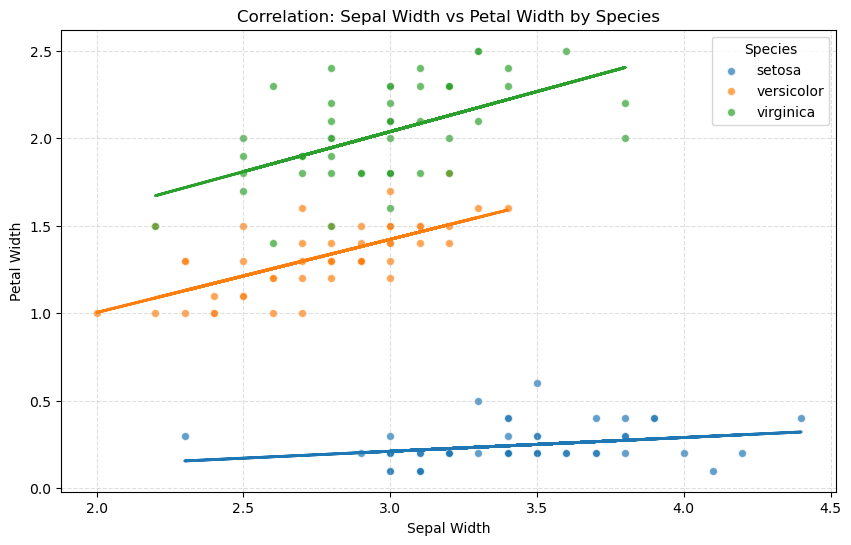

In [2]:
# Calculate correlation by species
width_correlation = iris_df.groupby('species')[['sepal_width', 'petal_width']].corr().round(2)
print(">> Correlation between Sepal and Petal Width by Species:\n")
print(width_correlation)

# Scatter plot with regression lines
plt.figure(figsize=(10, 6))

# Define colors for each species to maintain visual consistency
species_colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

for species, color in species_colors.items():
    # Filter data for the current species
    subset = iris_df[iris_df['species'] == species]
    x = subset['sepal_width']
    y = subset['petal_width']
    
    # Plot the scatter points
    plt.scatter(x, y, color=color, label=species, alpha=0.7, edgecolors='w')
    
    # Calculate linear regression line (y = mx + b)
    # np.polyfit returns [slope, intercept]
    m, b = np.polyfit(x, y, 1)
    
    # Add the regression line to the plot
    plt.plot(x, m*x + b, color=color, linewidth=2)

plt.title("Correlation: Sepal Width vs Petal Width by Species")
plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title="Species")

plt.show()

*Question:* **Any correlation between sepal and petal width by species?**

*Summary of Analysis:*

Based on the calculated Pearson correlation coefficients and the regression plot, there is a positive correlation between sepal width and petal width for all three species, but the strength of the relationship varies significantly:

* **Iris setosa:** Exhibits a weak positive correlation of approximately 0.28. The data points are more scattered, indicating that for this species, sepal width is not a strong predictor of petal width.
* **Iris versicolor:** Shows the strongest positive correlation at approximately 0.66. On the graph (orange line), we can see a clearer upward trend where an increase in sepal width generally corresponds to an increase in petal width.
* **Iris virginica:** Displays a moderate positive correlation of approximately 0.54. The green regression line shows a steady upward slope, confirming a visible relationship between the two measurements.

*Conclusion:* While all species show that widths tend to increase together, the correlation is most reliable in Iris versicolor and weakest in Iris setosa.

## *Research Question 2:*  **Any correlation between sepal and petal length by species?**

>> Correlation between Sepal and Petal Length by Species:

                         sepal_length  petal_length
species                                            
setosa     sepal_length          1.00          0.26
           petal_length          0.26          1.00
versicolor sepal_length          1.00          0.75
           petal_length          0.75          1.00
virginica  sepal_length          1.00          0.86
           petal_length          0.86          1.00


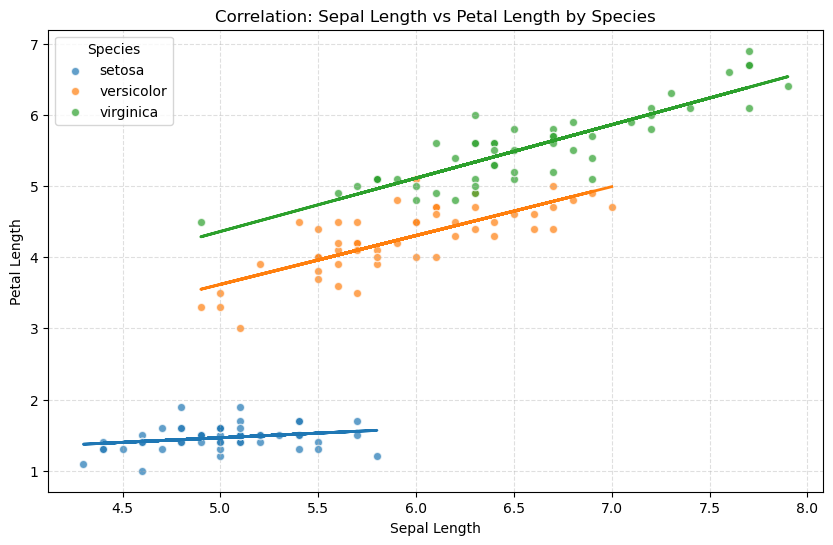

In [3]:
# Calculate correlation by species
length_correlation = iris_df.groupby('species')[['sepal_length', 'petal_length']].corr().round(2)
print(">> Correlation between Sepal and Petal Length by Species:\n")
print(length_correlation)

# Scatter plot with regression lines
plt.figure(figsize=(10, 6))

# Define colors for each species to maintain visual consistency
species_colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

for species, color in species_colors.items():
    # Filter data for the current species
    subset = iris_df[iris_df['species'] == species]
    x = subset['sepal_length']
    y = subset['petal_length']
    
    # Plot the scatter points
    plt.scatter(x, y, color=color, label=species, alpha=0.7, edgecolors='w')
    
    # Calculate linear regression line (y = mx + b)
    # np.polyfit returns [slope, intercept]
    m, b = np.polyfit(x, y, 1)
    
    # Add the regression line to the plot
    plt.plot(x, m*x + b, color=color, linewidth=2)

plt.title("Correlation: Sepal Length vs Petal Length by Species")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title="Species")

plt.show()

*Question:* **Any correlation between sepal and petal length by species?**

*Summary of Analysis:*

The analysis of sepal and petal lengths reveals a much stronger linear relationship compared to their widths. This is an important part of Predictive Modeling, as one variable can often predict the other.

* **Iris setosa:** Shows a weak to moderate positive correlation (typically around 0.26). Despite being a distinct group, the relationship between its length parameters is the least linear.
* **Iris versicolor:** Displays a strong positive correlation (typically around 0.75). The upward trend is very clear on the scatter plot.
* **Iris virginica:** Shows the strongest positive correlation (typically around 0.86). This indicates a very high degree of linear dependency between sepal and petal lengths for this species.

*Conclusion:* There is a strong positive correlation between sepal and petal lengths for the Versicolor and Virginica species. For Setosa, the relationship is present but much less pronounced.

## *Research Question 3:* **How are the sepal lengths distributed by species?**

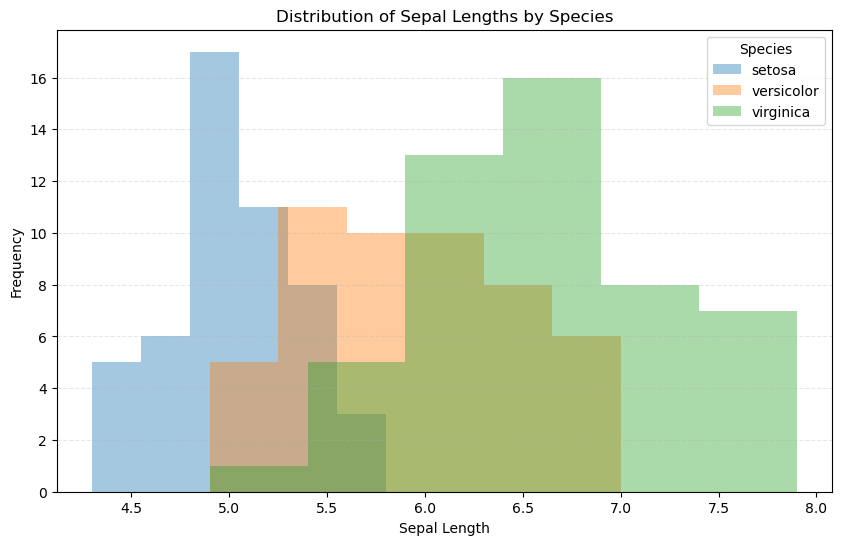

In [4]:
# Filter the dataset by species for separate plotting
setosa = iris_df[iris_df['species'] == 'setosa']['sepal_length']
versicolor = iris_df[iris_df['species'] == 'versicolor']['sepal_length']
virginica = iris_df[iris_df['species'] == 'virginica']['sepal_length']

# Create the distribution plot
plt.figure(figsize=(10, 6))

# Use alpha=0.4 for transparency and remove edgecolor to eliminate lines between bins
plt.hist(setosa, bins=6, alpha=0.4, label='setosa')
plt.hist(versicolor, bins=6, alpha=0.4, label='versicolor')
plt.hist(virginica, bins=6, alpha=0.4, label='virginica')

# Add clear labels and title to restate the research question
plt.title("Distribution of Sepal Lengths by Species")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.legend(title="Species")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

*Question:* **How are the sepal lengths distributed by species?**

*Summary of Analysis:*

Based on the distribution plot, we can observe the following:  

* **Iris Setosa:** Shows a narrow distribution with the shortest sepal lengths, mostly concentrated between 4.3 and 5.8 cm.
* **Iris Versicolor:** Has a wider distribution with average lengths higher than Setosa.
* **Iris Virginica:** Exhibits the largest sepal lengths, though its distribution significantly overlaps with Versicolor.

# **Final Summary and Assumption Validation**

*Research Overview:*
This project involved a comprehensive study of the Iris dataset to identify correlations between sepal and petal dimensions and to analyze the distribution of sepal lengths.

*Validating Initial Assumptions:*

* **Positive Relationship:** Confirmed. The correlation analysis showed positive coefficients for all species, proving that as dimensions increase, they generally do so together.

* **Species Variance (Setosa):** Confirmed. As predicted during the initial data exploration, Iris setosa exhibited the most distinct and weakest correlation patterns (~0.26-0.28) compared to other species. This aligns with its smaller scale and lower dispersion observed in the summary statistics.

* **Length vs. Width Correlation:** Confirmed. Our results showed that the correlation between lengths (up to 0.86) is significantly stronger than the correlation between widths (up to 0.66). Length is indeed a more dominant and predictable growth factor in these flowers.

*Conclusion:*
The data analysis process confirms that Iris virginica and Iris versicolor follow highly predictable linear growth patterns, while Iris setosa remains an outlier with unique biological characteristics. The integrity of the process was maintained by setting clear expectations and validating them through both statistical calculation and visualization.